# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## 🧩 Laberinto con `simpleai` — BFS, DFS, UCS e IDS
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/01b_Laberinto_simpleai.ipynb)

---

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Formular el **problema del laberinto** usando la clase `SearchProblem` de `simpleai`  
✅ Aplicar **BFS**, **DFS**, **UCS** e **IDS** de `simpleai` sobre el mismo laberinto 6×6  
✅ Comparar los caminos obtenidos con la librería vs. la implementación manual del notebook anterior  
✅ Entender cómo la abstracción `SearchProblem` generaliza la búsqueda a cualquier dominio  
✅ Visualizar y comparar los cuatro caminos con `matplotlib`

---

## 📖 Marco Teórico

### De la implementación manual a la librería

En el notebook anterior ([00 — Laberinto BFS y DFS](00_Laberinto_BFS_DFS.ipynb)) implementamos BFS y DFS **desde cero**: manejamos explícitamente la cola, la pila y el control de estados visitados.

Ahora reformulamos el **mismo laberinto** usando `simpleai`, la misma librería con la que resolvemos el Mapa de Rumanía. Esto ilustra una idea fundamental en IA:

> 💡 Un algoritmo de búsqueda es **independiente del dominio**. Solo necesita que el problema exponga: estados, acciones, transición y test de meta.

```
┌─────────────────────────────────────────────────┐
│              SearchProblem (simpleai)           │
│  ┌──────────────┐        ┌────────────────────┐ │
│  │ LaberintoProblem│    │  RomaniaProblem     │ │
│  │  estado=(r,c) │    │  estado='Arad'       │ │
│  │  acciones=    │    │  acciones=           │ │
│  │  ['abajo',…]  │    │  ['Zerind',…]        │ │
│  └──────────────┘        └────────────────────┘ │
│         ↓                         ↓             │
│   breadth_first()    uniform_cost()   depth_first() …
└─────────────────────────────────────────────────┘
```

### Resumen de algoritmos

| Algoritmo | Estrategia | Completo | Óptimo | Memoria |
|-----------|-----------|----------|--------|---------|
| **BFS** | Anchura — cola FIFO | ✅ Sí | ✅ Sí (costo uniforme) | Alta ⚠️ |
| **DFS** | Profundidad — pila LIFO | ⚠️ Sí (grafo finito) | ❌ No | Baja ✅ |
| **UCS** | Menor costo acumulado | ✅ Sí | ✅ Sí | Media |
| **IDS** | DFS con profundidad creciente | ✅ Sí | ✅ Sí (costo uniforme) | Baja ✅ |

> En el laberinto todos los pasos tienen costo 1, por lo tanto **BFS, UCS e IDS encuentran el camino óptimo**.

## 📦 Paso 1: Instalación e Imports

In [1]:
!pip install simpleai --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from simpleai.search import (
    SearchProblem,
    breadth_first,
    depth_first,
    uniform_cost,
    iterative_limited_depth_first,
)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🗺️ Paso 2: Definición del Laberinto

Usamos el mismo laberinto 6×6 del notebook anterior:
- **`0`** → celda transitable
- **`1`** → pared

```
  col→  0  1  2  3  4  5
fila 0 [·][·][·][·][·][■]
fila 1 [·][■][·][■][·][■]
fila 2 [·][■][·][·][·][·]
fila 3 [·][·][·][■][■][·]
fila 4 [·][■][·][·][·][·]
fila 5 [■][·][·][■][■][·]
```

Inicio: `(0, 0)` — Destino: `(5, 5)`

In [3]:
LABERINTO = np.array([
    [0, 0, 0, 0, 0, 1],
    [0, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 1, 0]
])

INICIO = (0, 0)
FIN    = (5, 5)

# Movimientos y sus nombres
MOVIMIENTOS = {
    'abajo':     ( 1,  0),
    'derecha':   ( 0,  1),
    'arriba':    (-1,  0),
    'izquierda': ( 0, -1),
}

print(f"Inicio : {INICIO}")
print(f"Fin    : {FIN}")
print(f"Celdas libres: {(LABERINTO == 0).sum()} — Paredes: {(LABERINTO == 1).sum()}")

Inicio : (0, 0)
Fin    : (5, 5)
Celdas libres: 25 — Paredes: 11


## 🖼️ Paso 3: Función de visualización y laberinto inicial

Reutilizamos la misma función de visualización del notebook anterior, adaptada para trabajar con los caminos que devuelve `simpleai`.

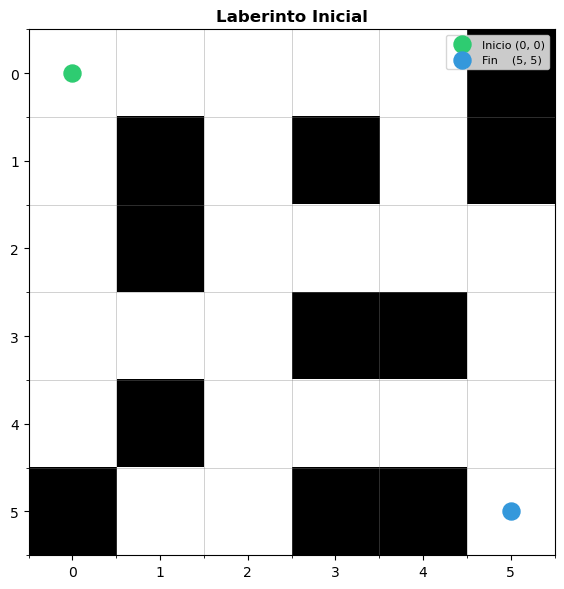

In [4]:
def mostrar_laberinto(laberinto, camino=None, titulo="Laberinto", ax=None):
    """
    Visualiza el laberinto y opcionalmente el camino encontrado.
    Acepta un Axes externo (ax) para graficación en subplots.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(laberinto, cmap="gray_r", vmin=0, vmax=1)

    if camino:
        xs, ys = zip(*camino)
        ax.plot(ys, xs, marker="o", color="#e74c3c",
                markersize=8, linewidth=2.5, label="Camino")

    ax.scatter(INICIO[1], INICIO[0], color="#2ecc71", s=150, zorder=5,
               label=f"Inicio {INICIO}")
    ax.scatter(FIN[1],    FIN[0],    color="#3498db", s=150, zorder=5,
               label=f"Fin    {FIN}")

    filas, cols = laberinto.shape
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.5, alpha=0.5)
    ax.set_xticks(range(cols))
    ax.set_yticks(range(filas))

    label = f"{titulo}  ({len(camino)} pasos)" if camino else titulo
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

    if standalone:
        plt.tight_layout()
        plt.show()


mostrar_laberinto(LABERINTO, titulo="Laberinto Inicial")

## 🧩 Paso 4: Formulación del Problema con `simpleai`

`simpleai` requiere definir el problema como una clase que hereda de `SearchProblem` e implementa:

| Método | Descripción |
|--------|-------------|
| `actions(state)` | Devuelve las acciones válidas desde el estado actual |
| `result(state, action)` | Aplica una acción y devuelve el nuevo estado |
| `is_goal(state)` | `True` si el estado es la meta |
| `cost(state, action, result)` | Costo de aplicar una acción (opcional; default = 1) |

Para el laberinto:
- **Estado**: tupla `(fila, columna)` — posición en la grilla
- **Acción**: string con el nombre del movimiento (`'abajo'`, `'derecha'`, `'arriba'`, `'izquierda'`)
- **Transición**: aplicar el desplazamiento correspondiente
- **Meta**: estado == `(5, 5)`
- **Costo**: 1 por paso (uniforme)

In [5]:
class LaberintoProblem(SearchProblem):
    """Problema del laberinto 6x6 formulado para simpleai."""

    def actions(self, state):
        """Devuelve los movimientos válidos desde la celda actual."""
        r, c = state
        valid = []
        for nombre, (dr, dc) in MOVIMIENTOS.items():
            nr, nc = r + dr, c + dc
            if (0 <= nr < LABERINTO.shape[0]
                    and 0 <= nc < LABERINTO.shape[1]
                    and LABERINTO[nr, nc] == 0):
                valid.append(nombre)
        return valid

    def result(self, state, action):
        """Aplica un movimiento y devuelve la nueva celda."""
        r, c = state
        dr, dc = MOVIMIENTOS[action]
        return (r + dr, c + dc)

    def is_goal(self, state):
        """La meta es alcanzar la esquina inferior derecha."""
        return state == FIN

    def cost(self, state, action, result_state):
        """Todos los pasos tienen costo 1 (laberinto sin pesos)."""
        return 1


def get_path(result):
    """Extrae la lista de estados (camino) y el costo total de un resultado de simpleai."""
    if result is None:
        return None, None
    path = [state for _, state in result.path()]
    return path, result.cost


# Verificación rápida
prob_test = LaberintoProblem(initial_state=INICIO)
print(f"✅ LaberintoProblem creado")
print(f"   Estado inicial : {INICIO}")
print(f"   Meta           : {FIN}")
print(f"   Acciones desde {INICIO}: {prob_test.actions(INICIO)}")
print(f"   Resultado de 'abajo' desde {INICIO}: {prob_test.result(INICIO, 'abajo')}")

✅ LaberintoProblem creado
   Estado inicial : (0, 0)
   Meta           : (5, 5)
   Acciones desde (0, 0): ['abajo', 'derecha']
   Resultado de 'abajo' desde (0, 0): (1, 0)


## 🔵 Paso 5: BFS — Búsqueda en Anchura

**BFS** explora nivel por nivel. Con costo uniforme (1 por paso), garantiza el **camino más corto**.

```
Cola (FIFO):  [(0,0)] → [(1,0),(0,1)] → [(2,0),(0,2),...] → ... → [(5,5)]
```

> `graph_search=True` activa el control de estados visitados para evitar ciclos.

In [6]:
result_bfs = breadth_first(
    LaberintoProblem(initial_state=INICIO),
    graph_search=True
)
path_bfs, cost_bfs = get_path(result_bfs)

print("🔵 BFS — Búsqueda en Anchura")
print(f"   Camino ({len(path_bfs)} pasos): {' → '.join(str(p) for p in path_bfs)}")
print(f"   Costo total: {cost_bfs}")

🔵 BFS — Búsqueda en Anchura
   Camino (11 pasos): (0, 0) → (1, 0) → (2, 0) → (3, 0) → (3, 1) → (3, 2) → (4, 2) → (4, 3) → (4, 4) → (4, 5) → (5, 5)
   Costo total: 10


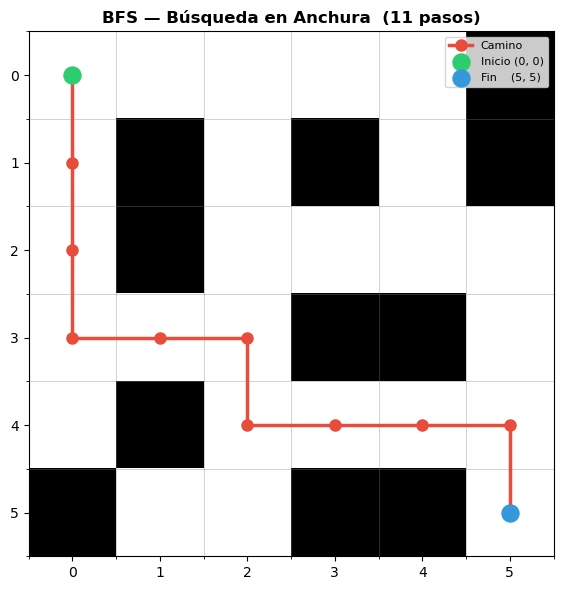

In [7]:
mostrar_laberinto(LABERINTO, path_bfs, "BFS — Búsqueda en Anchura")

## 🔴 Paso 6: DFS — Búsqueda en Profundidad

**DFS** desciende por ramas hasta el fondo antes de retroceder. Con `graph_search=True` evita ciclos.

```
Pila (LIFO): (0,0) → (1,0) → (2,0) → (3,0) → (3,1) → ...
```

> ⚠️ El camino encontrado por DFS depende del orden en que se generan los vecinos y **no garantiza ser el más corto**.

In [8]:
result_dfs = depth_first(
    LaberintoProblem(initial_state=INICIO),
    graph_search=True
)
path_dfs, cost_dfs = get_path(result_dfs)

print("🔴 DFS — Búsqueda en Profundidad")
print(f"   Camino ({len(path_dfs)} pasos): {' → '.join(str(p) for p in path_dfs)}")
print(f"   Costo total: {cost_dfs}")

🔴 DFS — Búsqueda en Profundidad
   Camino (15 pasos): (0, 0) → (0, 1) → (0, 2) → (0, 3) → (0, 4) → (1, 4) → (2, 4) → (2, 3) → (2, 2) → (3, 2) → (4, 2) → (4, 3) → (4, 4) → (4, 5) → (5, 5)
   Costo total: 14


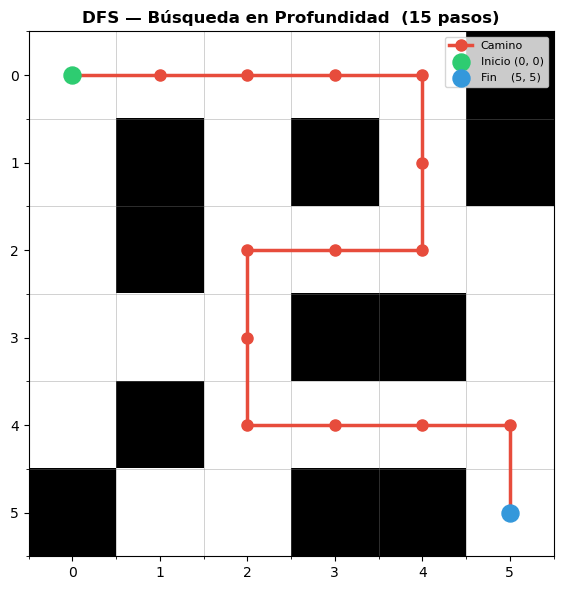

In [9]:
mostrar_laberinto(LABERINTO, path_dfs, "DFS — Búsqueda en Profundidad")

## 🟠 Paso 7: UCS — Búsqueda de Costo Uniforme

**UCS** expande el nodo con **menor costo acumulado** desde el inicio. Usa una cola de prioridad (min-heap).

> En el laberinto, todos los pasos cuestan 1, por lo que UCS explora igual que BFS y produce el **mismo camino óptimo**. La diferencia se vuelve relevante cuando los costos de las aristas varían.

In [10]:
result_ucs = uniform_cost(
    LaberintoProblem(initial_state=INICIO),
    graph_search=True
)
path_ucs, cost_ucs = get_path(result_ucs)

print("🟠 UCS — Búsqueda de Costo Uniforme")
print(f"   Camino ({len(path_ucs)} pasos): {' → '.join(str(p) for p in path_ucs)}")
print(f"   Costo total: {cost_ucs}  ← camino óptimo")

🟠 UCS — Búsqueda de Costo Uniforme
   Camino (11 pasos): (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (2, 3) → (2, 4) → (2, 5) → (3, 5) → (4, 5) → (5, 5)
   Costo total: 10  ← camino óptimo


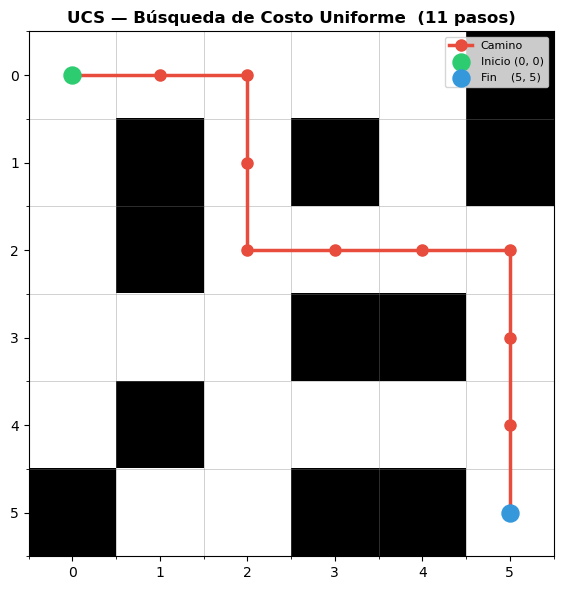

In [11]:
mostrar_laberinto(LABERINTO, path_ucs, "UCS — Búsqueda de Costo Uniforme")

## 🟢 Paso 8: IDS — Profundización Iterativa

**IDS** ejecuta DFS con un límite de profundidad creciente (1, 2, 3 …) hasta encontrar la solución.

```
Límite=1 → expande (0,0) y vecinos directos → no llega a (5,5)
Límite=2 → idem hasta nivel 2              → no llega a (5,5)
...
Límite=k → ¡(5,5) encontrado!
```

> IDS combina la **eficiencia en memoria de DFS** con la **optimalidad de BFS** (con costos uniformes).

In [12]:
result_ids = iterative_limited_depth_first(
    LaberintoProblem(initial_state=INICIO),
    graph_search=True
)
path_ids, cost_ids = get_path(result_ids)

print("🟢 IDS — Profundización Iterativa")
print(f"   Camino ({len(path_ids)} pasos): {' → '.join(str(p) for p in path_ids)}")
print(f"   Costo total: {cost_ids}")

🟢 IDS — Profundización Iterativa
   Camino (11 pasos): (0, 0) → (0, 1) → (0, 2) → (0, 3) → (0, 4) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5) → (5, 5)
   Costo total: 10


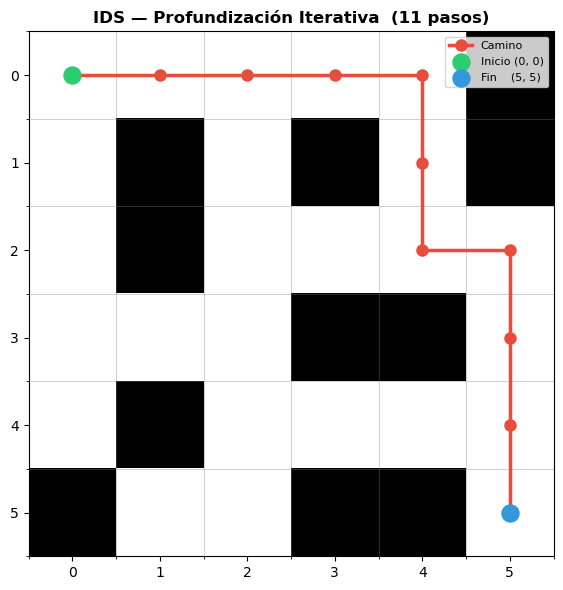

In [13]:
mostrar_laberinto(LABERINTO, path_ids, "IDS — Profundización Iterativa")

## 📊 Paso 9: Comparativa de los cuatro algoritmos

Comparamos los resultados y visualizamos los cuatro caminos lado a lado.

In [14]:
import pandas as pd

registros = [
    ('BFS',  path_bfs,  cost_bfs,  '✅ Sí', '✅ Sí (costo uniforme)', '⚠️ Alta',  'Cola FIFO'),
    ('DFS',  path_dfs,  cost_dfs,  '✅ Sí', '❌ No',                   '✅ Baja',  'Pila LIFO'),
    ('UCS',  path_ucs,  cost_ucs,  '✅ Sí', '✅ Sí',                   '⚠️ Media', 'Cola de prioridad'),
    ('IDS',  path_ids,  cost_ids,  '✅ Sí', '✅ Sí (costo uniforme)', '✅ Baja',  'DFS iterativo'),
]

df = pd.DataFrame(
    [(alg, len(p) if p else 'N/A', c, comp, opt, mem, struct)
     for alg, p, c, comp, opt, mem, struct in registros],
    columns=['Algoritmo', 'Pasos', 'Costo', 'Completo', 'Óptimo', 'Memoria', 'Estructura']
)

print("=== Comparativa de algoritmos sobre el laberinto ===")
print(df.to_string(index=False))

=== Comparativa de algoritmos sobre el laberinto ===
Algoritmo  Pasos  Costo Completo                Óptimo  Memoria        Estructura
      BFS     11     10     ✅ Sí ✅ Sí (costo uniforme)  ⚠️ Alta         Cola FIFO
      DFS     15     14     ✅ Sí                  ❌ No   ✅ Baja         Pila LIFO
      UCS     11     10     ✅ Sí                  ✅ Sí ⚠️ Media Cola de prioridad
      IDS     11     10     ✅ Sí ✅ Sí (costo uniforme)   ✅ Baja     DFS iterativo


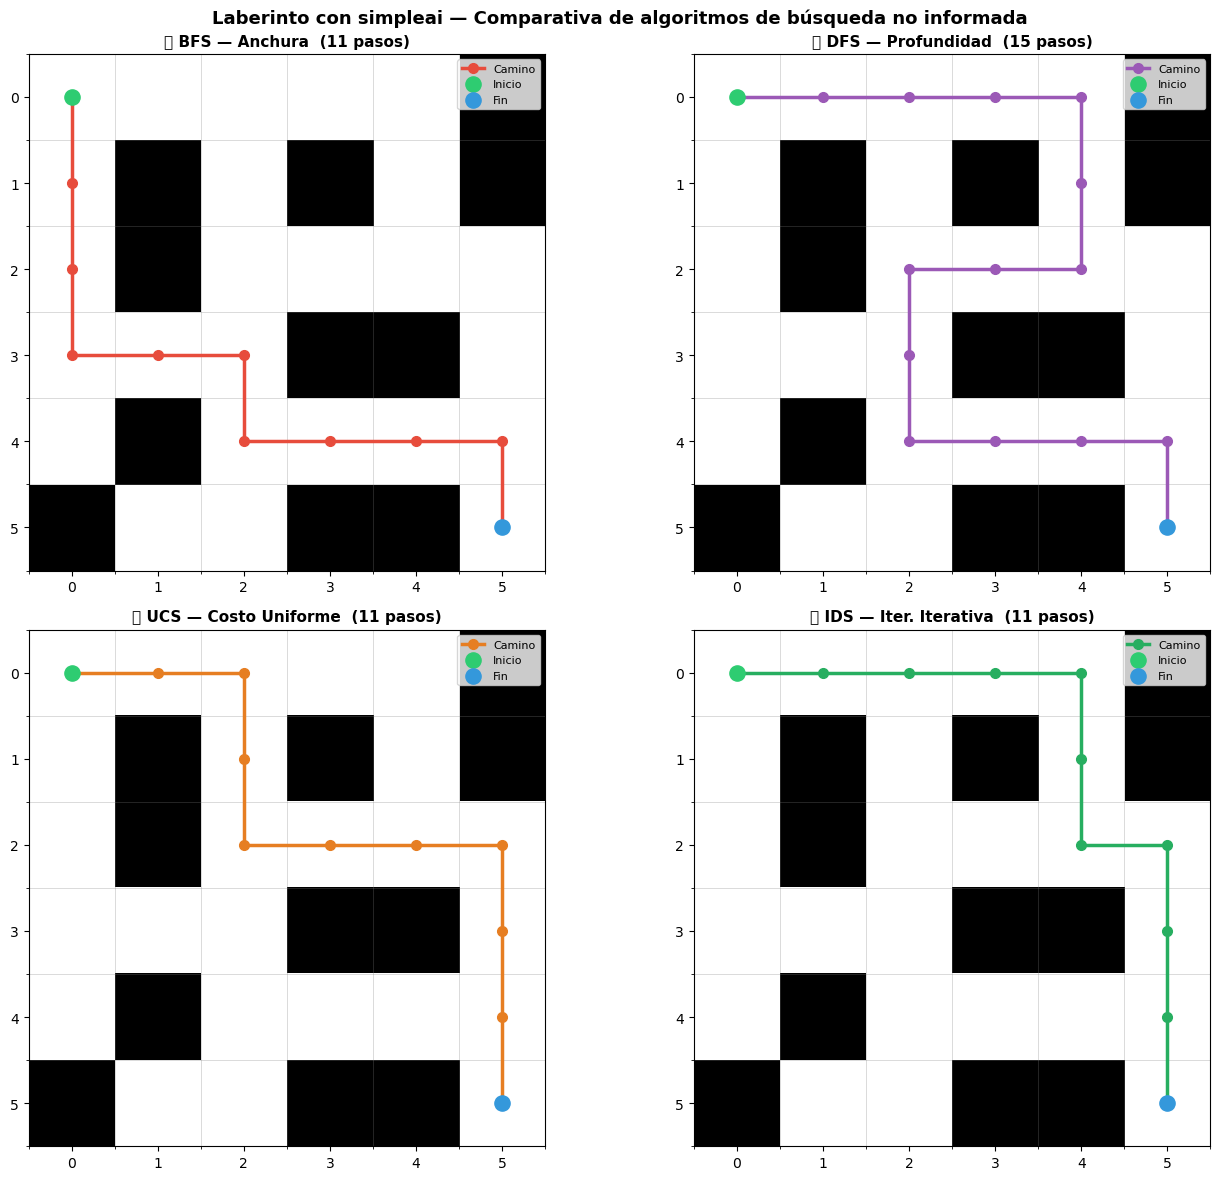

In [15]:
# Visualización 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

configs = [
    (path_bfs, "🔵 BFS — Anchura",       "#e74c3c"),
    (path_dfs, "🔴 DFS — Profundidad",    "#9b59b6"),
    (path_ucs, "🟠 UCS — Costo Uniforme", "#e67e22"),
    (path_ids, "🟢 IDS — Iter. Iterativa","#27ae60"),
]

for ax, (camino, titulo, color) in zip(axes, configs):
    ax.imshow(LABERINTO, cmap="gray_r", vmin=0, vmax=1)
    if camino:
        xs, ys = zip(*camino)
        ax.plot(ys, xs, marker="o", color=color,
                markersize=7, linewidth=2.5, label="Camino")
    ax.scatter(INICIO[1], INICIO[0], color="#2ecc71", s=120, zorder=5, label="Inicio")
    ax.scatter(FIN[1],    FIN[0],    color="#3498db", s=120, zorder=5, label="Fin")
    f, c = LABERINTO.shape
    ax.set_xticks(np.arange(-0.5, c, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, f, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.5, alpha=0.4)
    pasos = len(camino) if camino else '—'
    ax.set_title(f"{titulo}  ({pasos} pasos)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle(
    "Laberinto con simpleai — Comparativa de algoritmos de búsqueda no informada",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 🎓 Resumen y Conclusiones

### Puntos clave

1. `simpleai` **desacopla el algoritmo del dominio**: la misma clase `SearchProblem` y los mismos algoritmos sirven para el laberinto, el Mapa de Rumanía o cualquier otro problema de búsqueda.
2. **BFS, UCS e IDS** devuelven el camino óptimo (mismo número de pasos) cuando el costo por paso es uniforme.
3. **DFS** encontró un camino válido pero **generalmente más largo**, confirmando que no garantiza optimalidad.
4. `graph_search=True` es **esencial** en laberintos para evitar ciclos y estados repetidos.
5. La diferencia real entre BFS y UCS se manifiesta cuando los costos de las aristas son **variables** (ej.: Mapa de Rumanía con distancias en km).

### 🚀 ¿Qué sigue?

- **Búsqueda Informada (A\*)**: agregar una heurística de distancia Manhattan para guiar la búsqueda y reducir los nodos explorados → [03 — Búsqueda Informada](03_BusquedaInformada.ipynb)
- **Búsqueda Adversaria (Minimax)**: cuando un oponente toma decisiones en el mismo entorno → [04 — Búsqueda Adversaria](04_BusquedaAdversaria.ipynb)
- **Laberintos con pesos**: asignar costos distintos a cada celda para que UCS y A\* se diferencien de BFS.

### 📚 Referencias

- Russell & Norvig — *Artificial Intelligence: A Modern Approach* (4th ed.), Cap. 3.
- [simpleai — documentación oficial](https://simpleai.readthedocs.io/)
- Notebook anterior: [00 — Laberinto BFS y DFS (desde cero)](00_Laberinto_BFS_DFS.ipynb)
- Notebook siguiente: [03 — Búsqueda Informada](03_BusquedaInformada.ipynb)

---

*© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER*  
[![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/4.0/88x31.png)](https://creativecommons.org/licenses/by-sa/4.0/)